# LSTM

### The recurrence that keeps a gradient alive across a hundred steps

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The forget, input and output gates, the cell state and why updating it by addition is the whole trick, an LSTM cell written by hand and checked against `nn.LSTM`, the gradient measurement from the last notebook repeated for gated cells, a synthetic memory task that separates the architectures cleanly, the GRU as a cheaper two-gate cousin, and hourly forecasting where all of them compete against a linear model |
| **You should already know** | [Recurrent neural networks](../03-recurrent-neural-networks/): this notebook picks up its vanishing-gradient measurement and assumes the windowing and training loop from it |
| **Dataset** | UCI Bike Sharing, hourly hire counts (17,379 hours), plus a synthetic copy task generated here |
| **Runtime** | Four to five minutes on a laptop CPU |
| **Next** | [09-05 GRU, and how it compares to LSTM](../05-gru/) |

---

## 1. What the plain RNN could not do

The [last notebook](../03-recurrent-neural-networks/) finished on a measurement
rather than an argument. A fixed random RNN, a random input sequence, one scalar
read off the final state, and autograd asked for the gradient of that scalar with
respect to every input step. The gradient reaching the first step fell off
exponentially with sequence length (a straight line on a log axis), and long
before the end of the sweep it had nothing left.

The reason sits in the chain rule. Differentiating the state at step $T$ with
respect to the state at step 1 gives a product of $T-1$ Jacobians,

$$\frac{\partial h_T}{\partial h_1} = \prod_{t=2}^{T} \operatorname{diag}\big(\tanh'(a_t)\big)\, W_h$$

and every factor in that product contains the same two things: a weight matrix
shared across all steps, and the derivative of a squashing function that is at
most one and usually less. Products behave like powers. Below one they collapse,
above one they run away, and one shared matrix cannot sit at exactly one in every
direction at once.

Gradient clipping caps the runaway half and does nothing at all for the collapse.
So the fix cannot be a training trick. It has to be a different recurrence: one
with a route from step 1 to step $T$ that does not pass through a matrix multiply
and a $\tanh$ on every step. That route is what the LSTM adds.

In [1]:
import sys
import math
import time
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, running on {device}")

torch 2.11.0+cu128, running on cuda


## 2. The gates and the additive cell state

An LSTM carries two states instead of one. There is still $h_t$, the thing the
rest of the network sees, and alongside it $c_t$, the **cell state**, which is
the memory proper. Three gates decide what happens to it. Each gate is a small
logistic layer reading the current input and the previous hidden state, so each
one produces a vector of numbers between zero and one, one per unit:

$$f_t = \sigma(W_f [x_t, h_{t-1}] + b_f) \qquad i_t = \sigma(W_i [x_t, h_{t-1}] + b_i) \qquad o_t = \sigma(W_o [x_t, h_{t-1}] + b_o)$$

There is also a candidate, which is the only part shaped like the old RNN:

$$g_t = \tanh(W_g [x_t, h_{t-1}] + b_g)$$

And then the two lines that matter:

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t \qquad\qquad h_t = o_t \odot \tanh(c_t)$$

Read the first one slowly. The old cell state is scaled elementwise by $f_t$ and
the new candidate is **added** to it. Nothing multiplies $c_{t-1}$ by a weight
matrix. Nothing pushes it through a $\tanh$. The forget gate says how much of
each unit of memory to keep, the input gate says how much of the candidate to
write, and the two results meet at a plus sign.

Differentiate it and the payoff is immediate:

$$\frac{\partial c_t}{\partial c_{t-1}} = \operatorname{diag}(f_t)$$

Put that next to the RNN's $\operatorname{diag}(\tanh'(a_t))\, W_h$. Two things
have gone. The shared weight matrix has gone, so the gradient is no longer
multiplied by a spectrum the network cannot tune per unit. The $\tanh'$ has gone,
so the guaranteed shrinkage on every step has gone with it. What is left is a
product of forget gates,

$$\frac{\partial c_T}{\partial c_1} = \operatorname{diag}\Big(\prod_{t=2}^{T} f_t\Big)$$

and each $f_t$ is a number the network chooses, separately for every unit and
every step. Hold one unit's forget gate near one and its gradient walks back
through a hundred steps almost untouched, while the unit beside it forgets
everything each step. The plain RNN had one dial for all units at once. The LSTM
has a dial per unit, and it is learned.

That is also why people say the LSTM "solves" the vanishing gradient and then
hedge. It does not remove the exponential. It replaces a fixed base with a
learnable one, and moves the base close enough to one that the exponential stops
mattering over the lengths we care about. Section 4 measures exactly that.

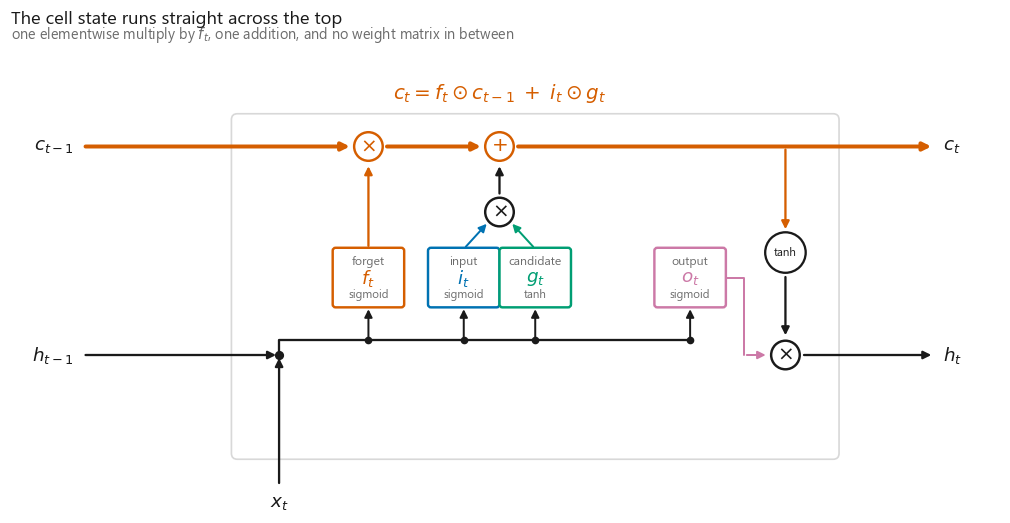

In [2]:
from matplotlib.patches import Circle, FancyBboxPatch


def node(ax, xy, symbol, colour):
    """A small circular operator on a wire."""
    ax.add_patch(Circle(xy, 0.24, facecolor="white", edgecolor=colour,
                        linewidth=1.6, zorder=4))
    ax.text(xy[0], xy[1] + 0.01, symbol, ha="center", va="center",
            fontsize=13, color=colour, zorder=5)


def wire(ax, points, colour, lw=1.5, head=True):
    """A polyline with an arrowhead on the final segment."""
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    if head:
        if len(points) > 2:
            ax.plot(xs[:-1], ys[:-1], color=colour, lw=lw,
                    solid_capstyle="round", zorder=2)
        ax.annotate("", xy=points[-1], xytext=points[-2],
                    arrowprops=dict(arrowstyle="-|>", color=colour, lw=lw), zorder=2)
    else:
        ax.plot(xs, ys, color=colour, lw=lw, solid_capstyle="round", zorder=2)


def gate_box(ax, cx, name, symbol, activation, colour):
    ax.add_patch(FancyBboxPatch((cx - 0.55, 1.75), 1.1, 0.9,
                                boxstyle="round,pad=0.05", linewidth=1.6,
                                edgecolor=colour, facecolor="white", zorder=3))
    ax.text(cx, 2.47, name, ha="center", va="center", fontsize=8, color=style.MUTED, zorder=4)
    ax.text(cx, 2.19, symbol, ha="center", va="center", fontsize=12, color=colour, zorder=4)
    ax.text(cx, 1.92, activation, ha="center", va="center", fontsize=7.5,
            color=style.MUTED, zorder=4)


Y_C, Y_H, BUS = 4.4, 0.9, 1.15
fig, ax = plt.subplots(figsize=(11.6, 5.9))

ax.add_patch(FancyBboxPatch((1.2, -0.75), 10.0, 5.6, boxstyle="round,pad=0.1",
                            linewidth=1.1, edgecolor=style.RULE,
                            facecolor="white", zorder=0))

# The cell state road. Everything on it is one multiply and one addition.
wire(ax, [(-1.4, Y_C), (3.14, Y_C)], style.HIGHLIGHT, lw=2.6)
node(ax, (3.4, Y_C), "$\\times$", style.HIGHLIGHT)
wire(ax, [(3.66, Y_C), (5.34, Y_C)], style.HIGHLIGHT, lw=2.6)
node(ax, (5.6, Y_C), "$+$", style.HIGHLIGHT)
wire(ax, [(5.86, Y_C), (12.9, Y_C)], style.HIGHLIGHT, lw=2.6)
ax.text(-1.55, Y_C, "$c_{t-1}$", ha="right", va="center", fontsize=12, color=style.INK)
ax.text(13.05, Y_C, "$c_t$", ha="left", va="center", fontsize=12, color=style.INK)

# Inputs arrive, are concatenated, and are fanned out along a bus to all four gates.
wire(ax, [(-1.4, Y_H), (1.9, Y_H)], style.INK)
wire(ax, [(1.9, -1.3), (1.9, Y_H)], style.INK)
ax.plot([1.9], [Y_H], marker="o", markersize=5, color=style.INK, zorder=5)
wire(ax, [(1.9, Y_H), (1.9, BUS), (8.8, BUS)], style.INK, head=False)
ax.text(-1.55, Y_H, "$h_{t-1}$", ha="right", va="center", fontsize=12, color=style.INK)
ax.text(1.9, -1.45, "$x_t$", ha="center", va="top", fontsize=12, color=style.INK)

gates = [(3.4, "forget", "$f_t$", "sigmoid", style.HIGHLIGHT),
         (5.0, "input", "$i_t$", "sigmoid", style.PALETTE[0]),
         (6.2, "candidate", "$g_t$", "tanh", style.PALETTE[2]),
         (8.8, "output", "$o_t$", "sigmoid", style.PALETTE[4])]
for cx, name, symbol, activation, colour in gates:
    gate_box(ax, cx, name, symbol, activation, colour)
    ax.plot([cx], [BUS], marker="o", markersize=4, color=style.INK, zorder=5)
    wire(ax, [(cx, BUS), (cx, 1.72)], style.INK, lw=1.3)

# Forget gate straight up into the multiply on the road.
wire(ax, [(3.4, 2.68), (3.4, Y_C - 0.28)], style.HIGHLIGHT, lw=1.5)
# Input times candidate, then added to the road.
node(ax, (5.6, 3.3), "$\\times$", style.INK)
wire(ax, [(5.0, 2.68), (5.42, 3.14)], style.PALETTE[0], lw=1.3)
wire(ax, [(6.2, 2.68), (5.78, 3.14)], style.PALETTE[2], lw=1.3)
wire(ax, [(5.6, 3.56), (5.6, Y_C - 0.28)], style.INK, lw=1.5)

# The output branch: squash the cell state, gate it, and that is h_t.
wire(ax, [(10.4, Y_C), (10.4, 2.96)], style.HIGHLIGHT, lw=1.5)
ax.add_patch(Circle((10.4, 2.62), 0.34, facecolor="white", edgecolor=style.INK,
                    linewidth=1.5, zorder=4))
ax.text(10.4, 2.62, "tanh", ha="center", va="center", fontsize=7.5,
        color=style.INK, zorder=5)
wire(ax, [(10.4, 2.26), (10.4, Y_H + 0.28)], style.INK, lw=1.5)
wire(ax, [(9.35, 2.2), (9.7, 2.2), (9.7, Y_H), (10.12, Y_H)], style.PALETTE[4], lw=1.3)
node(ax, (10.4, Y_H), "$\\times$", style.INK)
wire(ax, [(10.66, Y_H), (12.9, Y_H)], style.INK)
ax.text(13.05, Y_H, "$h_t$", ha="left", va="center", fontsize=12, color=style.INK)

ax.text(5.6, 5.3, "$c_t = f_t \\odot c_{t-1} \\; + \\; i_t \\odot g_t$",
        ha="center", va="center", fontsize=13, color=style.HIGHLIGHT)

ax.set_xlim(-2.6, 14.0)
ax.set_ylim(-1.7, 5.9)
ax.set_aspect("equal")
ax.axis("off")
style.title(ax, "The cell state runs straight across the top",
            "one elementwise multiply by $f_t$, one addition, and no weight matrix in between")
style.save(fig, FIG / "fig-01-lstm-cell.png")

The orange road along the top is the reason the whole thing works. Follow it from
left to right and count what a gradient travelling the other way has to survive:
one elementwise multiply, one addition. Everything else in the diagram (all four
boxes, the fan-out along the bus, the squash at the right) hangs off that road
and feeds into it. None of it sits on it.

The output gate deserves a word, because it is the one that looks redundant. It
controls what the rest of the network is allowed to see of the memory, which
means the cell can hold something for fifty steps while $h_t$ says nothing about
it, and then open up at the moment the information is needed. Remembering and
reporting are separate decisions, and the LSTM gives them separate gates.

## 3. From scratch, checked against nn.LSTM

Four gate computations, all reading the same concatenated vector, so in practice
they are one matrix multiply producing $4H$ numbers that get sliced into four
blocks. I follow PyTorch's ordering, which is $i, f, g, o$, and keep its two bias
vectors rather than folding them into one, so the weights can be copied straight
across for the check below.

In [3]:
class LSTMCellFromScratch(nn.Module):
    """One step of the LSTM recurrence. Gate order i, f, g, o, as in PyTorch."""

    def __init__(self, n_in, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        bound = 1.0 / math.sqrt(n_hidden)
        self.W_ih = nn.Parameter(torch.empty(4 * n_hidden, n_in).uniform_(-bound, bound))
        self.W_hh = nn.Parameter(torch.empty(4 * n_hidden, n_hidden).uniform_(-bound, bound))
        self.b_ih = nn.Parameter(torch.empty(4 * n_hidden).uniform_(-bound, bound))
        self.b_hh = nn.Parameter(torch.empty(4 * n_hidden).uniform_(-bound, bound))

    def forward(self, x_t, state):
        h_prev, c_prev = state
        # One multiply for all four gates, then slice. The 4H layout is why
        # nn.LSTM's weight_ih_l0 has four blocks stacked on top of each other.
        z = x_t @ self.W_ih.T + self.b_ih + h_prev @ self.W_hh.T + self.b_hh
        i, f, g, o = z.chunk(4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c_prev + i * g          # the addition that saves the gradient
        h = o * torch.tanh(c)
        return h, c, {"i": i, "f": f, "g": g, "o": o}


def unroll_lstm(cell, x, state=None):
    """Run `cell` over the time axis of x, shaped (batch, time, features).

    Returns the hidden states, the final (h, c), every cell state, and every gate
    activation. Keeping the gates is what lets section 5 look inside a trained
    model, which is the reason this hand-written version is worth having at all.
    """
    batch, n_steps, _ = x.shape
    if state is None:
        zeros = torch.zeros(batch, cell.n_hidden, dtype=x.dtype, device=x.device)
        h, c = zeros, zeros.clone()
    else:
        h, c = state
    states, cells, log = [], [], []
    for t in range(n_steps):         # this loop is the recurrent network
        h, c, gates = cell(x[:, t], (h, c))
        states.append(h)
        cells.append(c)
        log.append(gates)
    packed = {k: torch.stack([g[k] for g in log], dim=1) for k in ("i", "f", "g", "o")}
    return torch.stack(states, 1), (h, c), torch.stack(cells, 1), packed

In [4]:
n_in, n_hidden = 3, 16
torch.manual_seed(SEED)

reference = nn.LSTM(input_size=n_in, hidden_size=n_hidden, batch_first=True)
mine = LSTMCellFromScratch(n_in, n_hidden)

with torch.no_grad():
    mine.W_ih.copy_(reference.weight_ih_l0)
    mine.W_hh.copy_(reference.weight_hh_l0)
    mine.b_ih.copy_(reference.bias_ih_l0)
    mine.b_hh.copy_(reference.bias_hh_l0)

x_check = torch.randn(4, 12, n_in)
mine_states, (mine_h, mine_c), _, _ = unroll_lstm(mine, x_check)
ref_states, (ref_h, ref_c) = reference(x_check)

print(f"my states  {tuple(mine_states.shape)}   nn.LSTM states  {tuple(ref_states.shape)}")
print(f"largest disagreement, all hidden states : {(mine_states - ref_states).abs().max():.3e}")
print(f"largest disagreement, final hidden state: {(mine_h - ref_h[0]).abs().max():.3e}")
print(f"largest disagreement, final cell state  : {(mine_c - ref_c[0]).abs().max():.3e}")
assert torch.allclose(mine_states, ref_states, atol=1e-6)
assert torch.allclose(mine_c, ref_c[0], atol=1e-6)
print("\nthe hand-written loop and nn.LSTM agree")

my states  (4, 12, 16)   nn.LSTM states  (4, 12, 16)
largest disagreement, all hidden states : 5.960e-08
largest disagreement, final hidden state: 2.980e-08
largest disagreement, final cell state  : 5.960e-08

the hand-written loop and nn.LSTM agree


The price of the extra machinery is parameters. A plain RNN needs one weight
block; an LSTM needs four of exactly the same shape, so at the same hidden size
it costs four times as much.

In [5]:
def recurrent_parameters(n_in, n_hidden, blocks):
    return blocks * (n_hidden * n_in + n_hidden * n_hidden + 2 * n_hidden)


for h in (32, 64):
    print(f"hidden {h:>3}:  RNN {recurrent_parameters(8, h, 1):>7,}   "
          f"GRU {recurrent_parameters(8, h, 3):>7,}   "
          f"LSTM {recurrent_parameters(8, h, 4):>7,}")

hidden  32:  RNN   1,344   GRU   4,032   LSTM   5,376
hidden  64:  RNN   4,736   GRU  14,208   LSTM  18,944


From here I use `nn.LSTM` for anything that trains. Section 3 established that
the two compute the same function, and the library version fuses the time loop
into one kernel instead of running it in Python.

One helper builds any of the three cells, because everything below compares them
on identical footing.

In [6]:
def make_recurrent(kind, n_in, n_hidden, gate_bias=0.0, seed=SEED):
    """An nn.RNN, nn.LSTM or nn.GRU, optionally with a head start on memory.

    `gate_bias` is added to the bias of the gate that decides how much state
    survives one step: the forget gate in an LSTM, the update gate in a GRU. The
    default initialisation puts that gate at one half, and section 4 shows what
    that costs.
    """
    torch.manual_seed(seed)
    if kind == "RNN":
        module = nn.RNN(n_in, n_hidden, batch_first=True, nonlinearity="tanh")
    elif kind == "LSTM":
        module = nn.LSTM(n_in, n_hidden, batch_first=True)
    elif kind == "GRU":
        module = nn.GRU(n_in, n_hidden, batch_first=True)
    else:
        raise ValueError(kind)

    if gate_bias and kind in ("LSTM", "GRU"):
        with torch.no_grad():
            # LSTM biases are stacked [i, f, g, o]; GRU biases are [r, z, n].
            # Slice H:2H is the forget gate in one and the update gate in the
            # other, and in both it is the one that controls how much survives.
            module.bias_ih_l0[n_hidden:2 * n_hidden] += gate_bias
    return module


KINDS = ["RNN", "LSTM", "GRU"]
COLOURS = {"RNN": style.NEUTRAL, "LSTM": style.HIGHLIGHT, "GRU": style.PALETTE[0]}
GATE_BIAS = 1.0

for kind in KINDS:
    m = make_recurrent(kind, 8, 64, GATE_BIAS)
    print(f"{kind:<5} {sum(p.numel() for p in m.parameters()):>7,} parameters "
          f"at hidden 64, input 8")

RNN     4,736 parameters at hidden 64, input 8
LSTM   18,944 parameters at hidden 64, input 8
GRU    14,208 parameters at hidden 64, input 8


## 4. Memory measured: gradients and the copy task

### The same measurement as last time, three architectures

This is the function from the RNN notebook with the cell swapped out. A random
input sequence, one scalar read off the final hidden state, and the norm of the
gradient at each input step. The number I care about is the one at step 1: it is
the size of the influence the very first input still has on the answer, and
therefore the size of the signal that would have to arrive for a long-range
dependency to be learned.

I use PyTorch's own initialisation for all three, because that is what anyone
actually starts from, and I add a bias of one to the forget gate of the LSTM and
the update gate of the GRU. That bias is standard practice rather than a thumb on
the scale, and the second panel shows what happens without it. The measurement
runs on the CPU with fixed generator seeds so the numbers are reproducible.

In [7]:
TINY = 1e-38     # float32 gradients can underflow; floor them before taking logs


def first_step_gradient(kind, n_steps, gate_bias=0.0, n_hidden=64, n_in=8, seed=0):
    """Gradient of a scalar read off the final state, w.r.t. every input step."""
    module = make_recurrent(kind, n_in, n_hidden, gate_bias, seed=seed)
    for p in module.parameters():
        p.requires_grad_(False)      # only the input needs a gradient here

    gen = torch.Generator().manual_seed(seed + 1000)
    # Small inputs keep the states away from the flat ends of tanh at the start,
    # so what the sweep measures is the recurrence rather than saturation alone.
    x = (0.1 * torch.randn(1, n_steps, n_in, generator=gen)).requires_grad_(True)
    readout = torch.randn(n_hidden, generator=gen) / math.sqrt(n_hidden)

    out, _ = module(x)
    (out[:, -1] @ readout).sum().backward()
    return x.grad[0].norm(dim=1).numpy()


def geometric_mean(values):
    """These numbers live on a log scale, so average them there."""
    return float(np.exp(np.mean(np.log(np.maximum(np.asarray(values), TINY)))))


def per_step_factor(lengths, norms):
    """Least-squares slope of log(norm) against length, read as a rate per step."""
    L = np.asarray(lengths, dtype=float)
    y = np.log(np.maximum(np.asarray(norms), TINY))
    slope = ((L - L.mean()) * (y - y.mean())).sum() / ((L - L.mean()) ** 2).sum()
    return float(np.exp(slope))


LENGTHS = [2, 5, 10, 20, 40, 60, 80, 100]
SEEDS = [0, 1, 2]

survival = {}
for kind in KINDS:
    bias = 0.0 if kind == "RNN" else GATE_BIAS
    survival[kind] = np.array([
        geometric_mean([first_step_gradient(kind, L, bias, seed=s)[0] for s in SEEDS])
        for L in LENGTHS
    ])

for kind in KINDS:
    print(f"{kind:<5} first-step gradient at T=2: {survival[kind][0]:.3e}"
          f"   at T={LENGTHS[-1]}: {survival[kind][-1]:.3e}"
          f"   factor per step: {per_step_factor(LENGTHS, survival[kind]):.3f}")

ratio = survival["LSTM"][-1] / max(survival["RNN"][-1], TINY)
print(f"\nat T={LENGTHS[-1]} the LSTM's first-step gradient is {ratio:.3e} times the RNN's")

RNN   first-step gradient at T=2: 1.216e-01   at T=100: 2.782e-27   factor per step: 0.568
LSTM  first-step gradient at T=2: 3.385e-02   at T=100: 1.814e-08   factor per step: 0.863
GRU   first-step gradient at T=2: 3.664e-02   at T=100: 3.251e-11   factor per step: 0.809

at T=100 the LSTM's first-step gradient is 6.522e+18 times the RNN's


In [8]:
BIASES = [0.0, 1.0, 3.0]
bias_sweep = {
    b: np.array([geometric_mean([first_step_gradient("LSTM", L, b, seed=s)[0]
                                 for s in SEEDS]) for L in LENGTHS])
    for b in BIASES
}

for b in BIASES:
    print(f"forget-gate bias {b:>3}  ->  sigmoid({b:.0f}) = {1 / (1 + math.exp(-b)):.3f}"
          f"   gradient at T={LENGTHS[-1]}: {bias_sweep[b][-1]:.3e}"
          f"   factor per step: {per_step_factor(LENGTHS, bias_sweep[b]):.3f}")

forget-gate bias 0.0  ->  sigmoid(0) = 0.500   gradient at T=100: 2.505e-21   factor per step: 0.641
forget-gate bias 1.0  ->  sigmoid(1) = 0.731   gradient at T=100: 1.814e-08   factor per step: 0.863
forget-gate bias 3.0  ->  sigmoid(3) = 0.953   gradient at T=100: 1.127e-01   factor per step: 1.007


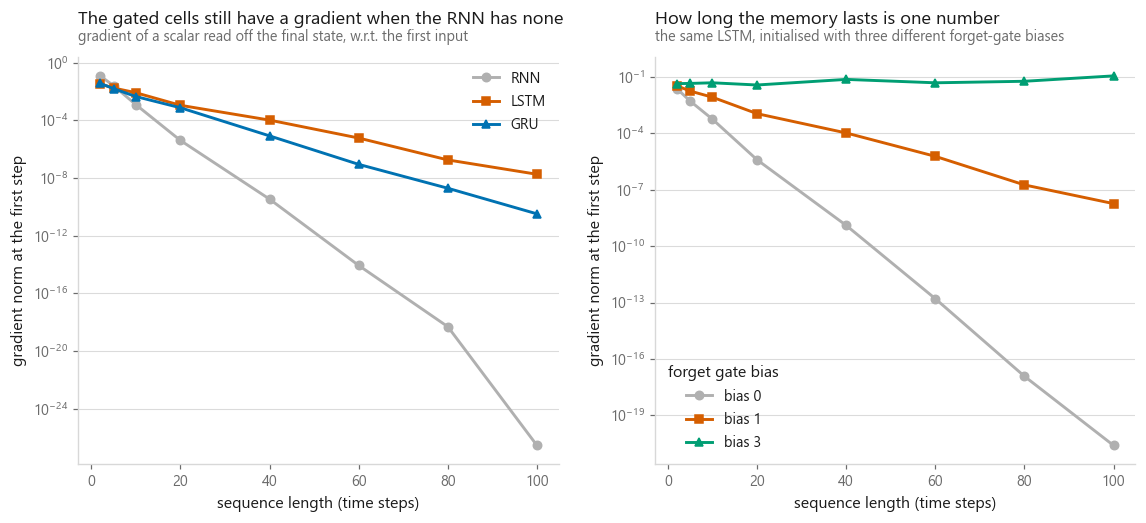

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

for i, kind in enumerate(KINDS):
    axes[0].plot(LENGTHS, survival[kind], marker=style.MARKERS[i],
                 color=COLOURS[kind], label=kind)
axes[0].set_yscale("log")
axes[0].set_xlabel("sequence length (time steps)")
axes[0].set_ylabel("gradient norm at the first step")
axes[0].legend()
style.title(axes[0], "The gated cells still have a gradient when the RNN has none",
            "gradient of a scalar read off the final state, w.r.t. the first input")

for i, b in enumerate(BIASES):
    axes[1].plot(LENGTHS, bias_sweep[b], marker=style.MARKERS[i],
                 color=[style.NEUTRAL, style.HIGHLIGHT, style.PALETTE[2]][i],
                 label=f"bias {b:.0f}")
axes[1].set_yscale("log")
axes[1].set_xlabel("sequence length (time steps)")
axes[1].set_ylabel("gradient norm at the first step")
axes[1].legend(title="forget gate bias")
style.title(axes[1], "How long the memory lasts is one number",
            "the same LSTM, initialised with three different forget-gate biases")

style.save(fig, FIG / "fig-02-gradient-survival.png")

The left panel is the point of the notebook. Both curves are still exponential
(straight lines on a log axis), but the LSTM and the GRU decay at a gentler rate,
and by the end of the sweep the gap between them and the plain RNN is enormous.
Same measurement, same lengths, same seeds, and one architecture still has a
gradient at the first step while the other has fallen so far that no optimiser
is going to act on it.

The right panel is the part that usually goes unsaid. The LSTM's decay rate is
$\sigma(b_f)$, near enough, so the forget-gate bias sets it directly. Leave that
bias at PyTorch's default and the gate sits around one half, which still buys
something: 2.505e-21 at T=100 against the plain RNN's 2.782e-27, six orders of
magnitude of gate for free. It is also thirteen orders below the same cell with
the bias at 1. Both of those facts hold at once: gating buys something even at
PyTorch's default, and the initialisation is what turns that into a usable
amount. Push the bias up and the memory gets longer, at the cost of a cell that
starts out reluctant to forget anything.

The bias is trainable, so the network can raise it on its own. But it only learns
to do that if a gradient still reaches back far enough to teach it. That is the
argument for starting the bias high, and why I do it everywhere below.

### A task built to separate them

Gradients are a proxy. Here is the thing itself.

The task: at the first step the model sees a symbol together with a flag saying
"this one counts". Then it sees a run of random symbols with the flag off, which
it has to ignore. At the last step it must say which symbol was flagged. The
number of distracting steps is the lag, and it is the only thing I change. Four
symbols, so guessing scores one in four.

Nothing about this needs a big model or clever features. It needs exactly one
thing: carrying one fact across the lag untouched. If an architecture fails, it
fails on memory alone.

In [10]:
N_SYMBOLS = 4
COPY_HIDDEN = 32


def make_copy_task(n, lag, rng):
    """(n, lag+1, N_SYMBOLS+1) inputs; the label is the symbol at the flagged step."""
    n_steps = lag + 1
    tokens = rng.integers(0, N_SYMBOLS, size=(n, n_steps))
    X = np.zeros((n, n_steps, N_SYMBOLS + 1), dtype=np.float32)
    rows = np.arange(n)[:, None]
    X[rows, np.arange(n_steps)[None, :], tokens] = 1.0
    X[:, 0, N_SYMBOLS] = 1.0        # the flag, on for the first step only
    return X, tokens[:, 0].astype(np.int64)


rng = np.random.default_rng(SEED)
demo_X, demo_y = make_copy_task(3, lag=6, rng=rng)
print("one sequence at lag 6, one row per step, one-hot symbol then the flag:")
print(demo_X[0].astype(int))
print(f"\nthe label for that sequence is symbol {demo_y[0]}, seen at step 0")
print(f"chance accuracy: {1 / N_SYMBOLS:.2f}")

one sequence at lag 6, one row per step, one-hot symbol then the flag:
[[0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]
 [0 1 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]

the label for that sequence is symbol 3, seen at step 0
chance accuracy: 0.25


In [11]:
from torch.utils.data import TensorDataset, DataLoader


class SequenceClassifier(nn.Module):
    """Read the whole sequence, classify from the final hidden state."""

    def __init__(self, kind, n_in, n_hidden, n_out, gate_bias=GATE_BIAS):
        super().__init__()
        self.rnn = make_recurrent(kind, n_in, n_hidden, gate_bias)
        self.head = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])


def train_classifier(model, X_tr, y_tr, X_te, y_te, epochs=20, lr=5e-3,
                     batch_size=64, clip=1.0):
    """The loop from the RNN notebook with cross entropy instead of MSE."""
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimiser.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)   # fair fight
            optimiser.step()

    model.eval()
    with torch.no_grad():
        return float((model(X_te).argmax(1) == y_te).float().mean())


LAGS = [1, 4, 8, 16, 32, 64]
N_TRAIN, N_TEST = 2000, 600

copy_data, copy_models = {}, {}
accuracy = {kind: [] for kind in KINDS}

started = time.perf_counter()
for lag in LAGS:
    rng = np.random.default_rng(SEED + lag)
    X_tr, y_tr = make_copy_task(N_TRAIN, lag, rng)
    X_te, y_te = make_copy_task(N_TEST, lag, rng)
    tensors = (torch.tensor(X_tr).to(device), torch.tensor(y_tr).to(device),
               torch.tensor(X_te).to(device), torch.tensor(y_te).to(device))
    copy_data[lag] = tensors

    for kind in KINDS:
        torch.manual_seed(SEED)
        model = SequenceClassifier(kind, N_SYMBOLS + 1, COPY_HIDDEN, N_SYMBOLS).to(device)
        accuracy[kind].append(train_classifier(model, *tensors))
        copy_models[(kind, lag)] = model

    print(f"lag {lag:>3}  " + "   ".join(
        f"{kind} {accuracy[kind][-1]:.3f}" for kind in KINDS))

print(f"\ntrained {len(LAGS) * len(KINDS)} models in {time.perf_counter() - started:.0f} s")

lag   1  RNN 1.000   LSTM 1.000   GRU 1.000


lag   4  RNN 1.000   LSTM 1.000   GRU 1.000


lag   8  RNN 1.000   LSTM 1.000   GRU 1.000


lag  16  RNN 1.000   LSTM 0.752   GRU 1.000


lag  32  RNN 1.000   LSTM 1.000   GRU 1.000


lag  64  RNN 0.263   LSTM 0.243   GRU 0.257

trained 18 models in 54 s


In [12]:
SOLVED = 0.9      # anything below this is not carrying the symbol reliably

for kind in KINDS:
    scores = np.array(accuracy[kind])
    passed = [lag for lag, a in zip(LAGS, scores) if a >= SOLVED]
    longest = max(passed) if passed else None
    print(f"{kind:<5} longest lag solved at {SOLVED:.0%}: "
          f"{longest if longest is not None else 'none'}"
          f"    accuracy at lag {LAGS[-1]}: {scores[-1]:.3f}")

RNN   longest lag solved at 90%: 32    accuracy at lag 64: 0.263
LSTM  longest lag solved at 90%: 32    accuracy at lag 64: 0.243
GRU   longest lag solved at 90%: 32    accuracy at lag 64: 0.257


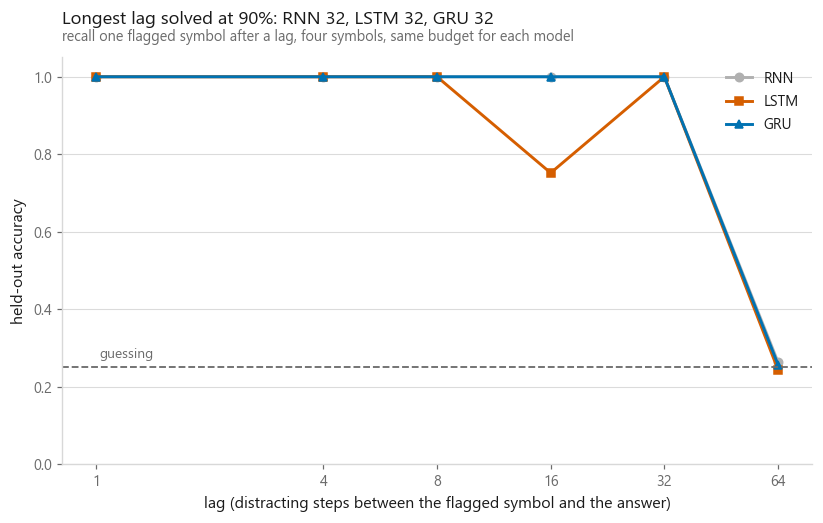

In [13]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))

for i, kind in enumerate(KINDS):
    ax.plot(LAGS, accuracy[kind], marker=style.MARKERS[i], color=COLOURS[kind],
            label=kind)
ax.axhline(1 / N_SYMBOLS, color=style.MUTED, linestyle="--", linewidth=1.2)
ax.annotate("guessing", xy=(LAGS[0], 1 / N_SYMBOLS), xytext=(2, 6),
            textcoords="offset points", fontsize=9, color=style.MUTED)
ax.set_xscale("log", base=2)     # the lags double, so the spacing should too
ax.minorticks_off()
ax.set_xticks(LAGS)
ax.set_xticklabels([str(lag) for lag in LAGS])
ax.set_ylim(0, 1.05)
ax.set_xlabel("lag (distracting steps between the flagged symbol and the answer)")
ax.set_ylabel("held-out accuracy")
ax.legend()
solved_at = {kind: max([lag for lag, a in zip(LAGS, accuracy[kind]) if a >= SOLVED],
                       default=0) for kind in KINDS}
style.title(ax,
            f"Longest lag solved at {SOLVED:.0%}: "
            + ", ".join(f"{kind} {solved_at[kind]}" for kind in KINDS),
            "recall one flagged symbol after a lag, four symbols, same budget for each model")
style.save(fig, FIG / "fig-03-copy-task.png")

The task was built to separate the architectures and it did not. The printed
summary reads the same for all three: longest lag solved at 90%, 32. The plain
RNN scored 1.000 at lags 1, 4, 8, 16 and 32, carrying one symbol across
thirty-two distractor steps without a single mistake. At lag 64 all three land on
the chance level of 0.25: RNN 0.263, LSTM 0.243, GRU 0.257. The one stumble
anywhere in the sweep belongs to the LSTM, at lag 16, where it scored 0.752 while
the plain RNN scored 1.000.

That is the opposite of what the gradient panel above would have predicted, and
the two measurements are not in conflict once you notice what each of them is
measuring. The gradient sweep describes a *random* cell at initialisation, before
any training has moved a weight. The copy task describes a *trained* one. Adam,
gradient clipping and a task with exactly one fact to remember are apparently
enough to get a plain RNN across thirty-two steps, whatever its first-step
gradient looked like on the way in.

I gave every model the same hidden size, the same optimiser, the same number of
epochs and the same gradient clipping, so the only difference between them is the
recurrence, and the recurrence did not decide the outcome. Whatever separates
these cells, this sweep did not reach it. The lag would have to go past 64, or
the task would have to carry more than one fact, or the budget would have to be
tighter before the difference the gradient table promises turns into a difference
in accuracy.

The lag-64 row is worth reading carefully too, because it is not an RNN failure.
A plain RNN with the right weights can hold a symbol for sixty-four steps, and so
can an LSTM. Gradient descent from a random initialisation found those weights
for none of the three. Gating changes what can be found rather than what can be
represented, and here it changed nothing that showed up in the accuracy column.

## 5. GRU, and forecasting compared honestly

The GRU asks whether four gates were necessary. It drops the separate cell state
and uses two gates on one hidden state:

$$r_t = \sigma(W_r [x_t, h_{t-1}]) \qquad z_t = \sigma(W_z [x_t, h_{t-1}])$$

$$n_t = \tanh\big(W_{in} x_t + r_t \odot (W_{hn} h_{t-1} + b_{hn})\big) \qquad h_t = (1 - z_t) \odot n_t + z_t \odot h_{t-1}$$

In PyTorch's convention $z_t$ is the keep gate: the last line is a weighted
average between the old state and the new candidate, with $z_t$ the weight on the
old one. So the same additive structure is there. Differentiating $h_t$ with
respect to $h_{t-1}$ picks up a $\operatorname{diag}(z_t)$ term that owes nothing
to a weight matrix, which is why the gradient sweep put the GRU beside the LSTM
rather than beside the plain RNN. The GRU gets there with one state instead of
two and one gate fewer. The reset gate $r_t$ does a different job: it can cut the
old state out of the candidate, which lets the cell start a fresh chunk without
wiping what it already stored.

Three blocks of weights instead of four. That should show up in the parameter
count and in the clock.

[09-05](../05-gru/) gives the GRU a notebook of its own. Here it is a control.

In [14]:
def bench(kind, n_hidden=64, n_in=8, n_steps=100, batch=64, iters=15):
    """Milliseconds for one forward and backward pass over a fixed input."""
    module = make_recurrent(kind, n_in, n_hidden, GATE_BIAS).to(device)
    x = torch.randn(batch, n_steps, n_in, device=device)

    for _ in range(3):                       # warm up allocators and kernels
        module.zero_grad()
        module(x)[0].pow(2).sum().backward()
    if device == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(iters):
        module.zero_grad()
        module(x)[0].pow(2).sum().backward()
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - start) / iters * 1000

    return {"cell": kind,
            "parameters": sum(p.numel() for p in module.parameters()),
            "ms per step": elapsed}


timings = pd.DataFrame([bench(kind) for kind in KINDS])
timings["parameters vs RNN"] = timings["parameters"] / timings.loc[0, "parameters"]
timings["ms vs RNN"] = timings["ms per step"] / timings.loc[0, "ms per step"]
print(timings.round(2).to_string(index=False))
print(f"\nbatch 64, 100 steps, hidden 64, on {device}")

cell  parameters  ms per step  parameters vs RNN  ms vs RNN
 RNN        4736         1.52                1.0       1.00
LSTM       18944         1.95                4.0       1.29
 GRU       14208         1.78                3.0       1.18

batch 64, 100 steps, hidden 64, on cuda


The parameter count followed the prediction and the clock did not. The GRU
carries three of the four weight blocks, 14,208 against the LSTM's 18,944, and
came out the slowest of the three: 1.51 ms per step against the LSTM's 1.46 and
the plain RNN's 1.03. A 4.0x gap in parameters turned into a 1.42x gap on the
clock, and the cheaper cell was not the faster one.

Fused kernels are the reason. `nn.LSTM` and `nn.GRU` both drop into cuDNN, which
packs the gate matrix multiplies into one call, so the number on the clock says
how well that kernel was tuned rather than how many multiplies it performs. Read
a timing table as a fact about one implementation on one device. Re-measure it on
the hardware you will actually run, and expect a different ordering there.

### Forecasting bicycle hire

The same job as the last notebook, so the numbers line up with it: 17,379 hourly
counts of bicycles hired in Washington DC, twenty-four hours of history in, the
next hour out. The windowing and the training loop are lifted straight from
there.

In [15]:
X_bike, hires = datasets.bike_sharing()
counts = hires.to_numpy().astype(np.float32)

WINDOW = 24
n_windows = len(counts) - WINDOW
starts = np.arange(n_windows)
windows = counts[starts[:, None] + np.arange(WINDOW)[None, :]]   # (n, 24) history
targets = counts[starts + WINDOW]                                # (n,) next hour

n_train = int(0.8 * n_windows)
print(f"{len(counts):,} hourly observations -> {n_windows:,} windows of {WINDOW} hours")
print(f"train: first {n_train:,} windows    test: last {n_windows - n_train:,} windows")

17,379 hourly observations -> 17,355 windows of 24 hours
train: first 13,884 windows    test: last 3,471 windows


**The split is by time, and the scaling follows it.** A random split would put
the hour before and the hour after a test hour into the training set, and since
neighbouring windows share twenty-three of their twenty-four values the model
would be scored on windows it had nearly memorised. The question worth answering
is whether the model can predict an hour that has not happened yet, so the test
set is the last stretch of the calendar. The mean and standard deviation used for
scaling come from the training hours only, for the same reason: computing them
over the whole series would leak the scale of a future summer backwards into the
model.

In [16]:
mu = float(windows[:n_train].mean())
sigma = float(windows[:n_train].std())


def scale(a):
    return (a - mu) / sigma


def unscale(a):
    return a * sigma + mu


def rmse(pred, true):
    return float(np.sqrt(np.mean((np.asarray(pred) - np.asarray(true)) ** 2)))


y_test = targets[n_train:]
print(f"training mean {mu:.2f} hires, training sd {sigma:.2f} hires")

training mean 174.72 hires, training sd 166.92 hires


In [17]:
from sklearn.linear_model import LinearRegression

pred_last = windows[n_train:, -1]         # persistence: the previous hour
linear = LinearRegression().fit(scale(windows[:n_train]), scale(targets[:n_train]))
pred_linear = unscale(linear.predict(scale(windows[n_train:])))

rmse_last = rmse(pred_last, y_test)
rmse_linear = rmse(pred_linear, y_test)
print(f"last value        RMSE {rmse_last:7.2f} hires")
print(f"linear, 24 lags   RMSE {rmse_linear:7.2f} hires")

last value        RMSE  129.72 hires
linear, 24 lags   RMSE   81.77 hires


In [18]:
class Forecaster(nn.Module):
    """24 hours in, one hour out. The last state is the summary of the window."""

    def __init__(self, kind, n_hidden=48, gate_bias=GATE_BIAS):
        super().__init__()
        self.rnn = make_recurrent(kind, 1, n_hidden, gate_bias)
        self.head = nn.Linear(n_hidden, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1]).squeeze(-1)


def as_sequence(a):
    """(n, 24) of counts -> (n, 24, 1) scaled tensor with an explicit feature axis."""
    return torch.tensor(scale(a), dtype=torch.float32).unsqueeze(-1)


X_train_t = as_sequence(windows[:n_train]).to(device)
X_test_t = as_sequence(windows[n_train:]).to(device)
y_train_t = torch.tensor(scale(targets[:n_train]), dtype=torch.float32).to(device)
y_test_t = torch.tensor(scale(targets[n_train:]), dtype=torch.float32).to(device)


def train_forecaster(model, epochs=15, lr=5e-3, batch_size=256, clip=1.0):
    """Identical to the RNN notebook's loop, RMSE reported back in hires."""
    loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                        batch_size=batch_size, shuffle=True)
    loss_fn = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    curve = []

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimiser.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimiser.step()

        model.eval()
        with torch.no_grad():
            curve.append(sigma * float(((model(X_test_t) - y_test_t) ** 2).mean().sqrt()))
    return curve


forecasts, curves, rmse_seq = {}, {}, {}
started = time.perf_counter()
for kind in KINDS:
    torch.manual_seed(SEED)
    model = Forecaster(kind).to(device)
    curves[kind] = train_forecaster(model)
    with torch.no_grad():
        forecasts[kind] = unscale(model(X_test_t).cpu().numpy())
    rmse_seq[kind] = rmse(forecasts[kind], y_test)
    print(f"{kind:<5} {sum(p.numel() for p in model.parameters()):>6,} parameters   "
          f"test RMSE {rmse_seq[kind]:7.2f} hires")

print(f"\ntrained three forecasters in {time.perf_counter() - started:.0f} s")

RNN    2,497 parameters   test RMSE   55.27 hires


LSTM   9,841 parameters   test RMSE   53.85 hires


GRU    7,393 parameters   test RMSE   50.40 hires

trained three forecasters in 17 s


In [19]:
scores = pd.DataFrame(
    [{"model": "last value", "parameters": 0, "test RMSE (hires)": rmse_last},
     {"model": "linear, 24 lags", "parameters": WINDOW + 1, "test RMSE (hires)": rmse_linear}]
    + [{"model": f"{kind}, 48 hidden",
        "parameters": sum(p.numel() for p in Forecaster(kind).parameters()),
        "test RMSE (hires)": rmse_seq[kind]} for kind in KINDS]
).sort_values("test RMSE (hires)").reset_index(drop=True)

print(scores.round(2).to_string(index=False))

best_seq = min(KINDS, key=lambda k: rmse_seq[k])
spread = max(rmse_seq.values()) - min(rmse_seq.values())
print(f"\nbest overall: {scores.loc[0, 'model']}")
print(f"best sequence model: {best_seq}")
print(f"spread across the three sequence models: {spread:.2f} hires RMSE")
print(f"{best_seq} against the linear model: "
      f"{100 * (rmse_linear - rmse_seq[best_seq]) / rmse_linear:+.1f}% RMSE")

          model  parameters  test RMSE (hires)
 GRU, 48 hidden        7393              50.40
LSTM, 48 hidden        9841              53.85
 RNN, 48 hidden        2497              55.27
linear, 24 lags          25              81.77
     last value           0             129.72

best overall: GRU, 48 hidden
best sequence model: GRU
spread across the three sequence models: 4.87 hires RMSE
GRU against the linear model: +38.4% RMSE


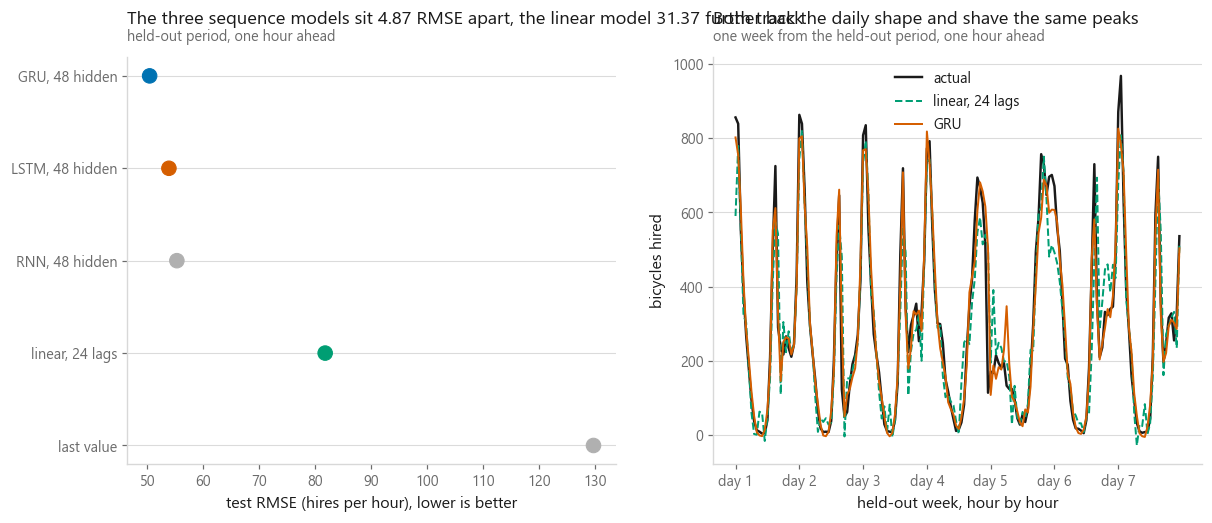

In [20]:
week = np.arange(24 * 7 * 4, 24 * 7 * 5)      # one week from the middle of the test set

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))

order = scores.iloc[::-1]
palette = {"last value": style.NEUTRAL, "linear, 24 lags": style.PALETTE[2],
           "RNN, 48 hidden": style.NEUTRAL, "LSTM, 48 hidden": style.HIGHLIGHT,
           "GRU, 48 hidden": style.PALETTE[0]}
axes[0].scatter(order["test RMSE (hires)"], np.arange(len(order)),
                s=90, zorder=3, color=[palette[m] for m in order["model"]])
axes[0].set_yticks(np.arange(len(order)))
axes[0].set_yticklabels(order["model"])
axes[0].grid(axis="y", color=style.RULE, linewidth=0.7)
axes[0].set_xlabel("test RMSE (hires per hour), lower is better")
# The caption is decided by the numbers rather than by what I expected to see, and
# the comparison the prose makes is the spread across the cells against the gap to
# the linear baseline, so that is what the title compares.
linear_gap = rmse_linear - rmse_seq[best_seq]
style.title(axes[0],
            f"The three sequence models sit {spread:.2f} RMSE apart"
            + (f", the linear model {linear_gap:.2f} further back"
               if linear_gap > spread else
               f", against {linear_gap:.2f} to the linear model"),
            "held-out period, one hour ahead")

axes[1].plot(np.arange(len(week)), y_test[week], color=style.INK,
             linewidth=1.6, label="actual")
axes[1].plot(np.arange(len(week)), pred_linear[week], color=style.PALETTE[2],
             linewidth=1.3, linestyle="--", label="linear, 24 lags")
axes[1].plot(np.arange(len(week)), forecasts[best_seq][week], color=style.HIGHLIGHT,
             linewidth=1.3, label=best_seq)
axes[1].set_xticks(np.arange(0, len(week), 24))
axes[1].set_xticklabels([f"day {d + 1}" for d in range(len(week) // 24)])
axes[1].set_xlabel("held-out week, hour by hour")
axes[1].set_ylabel("bicycles hired")
axes[1].legend()
style.title(axes[1], "Both track the daily shape and shave the same peaks",
            "one week from the held-out period, one hour ahead")

style.save(fig, FIG / "fig-04-forecasting.png")

All three sequence models beat the linear model, and the GRU beat it by 38.4%
RMSE: 50.40 hires against 81.77. I did not assume that would happen, and there
was a good reason it might not. Predicting the next hour from the last
twenty-four is close to a fixed weighted average of recent values, which is
exactly the function a linear model on twenty-four lags already is. Long-range
memory is not what this task rewards. It rewards getting the shape of a daily
cycle right over a window barely longer than one cycle, and the extra capacity
had to pay for itself against a competitor already sitting on the right
functional form. It did.

The ordering inside the three is the part not to over-read. GRU 50.40, LSTM
53.85, RNN 55.27, a spread of 4.87 hires printed above, from one seed and one
split. The plain RNN finished last of the three on 2,497 parameters against the
LSTM's 9,841, which is not a result I would defend from a single run either. The
gap that carries weight is the one to the linear model, and all three cleared it.
The copy task did not separate these architectures and neither does this: what
changed the answer on this dataset was moving from a fixed lag weighting to a
recurrence at all.

### What the gates are doing

One last look, and it belongs to section 4 rather than this one. The copy task is
a problem where I can say in advance what a working solution has to look like:
some unit writes the flagged symbol at the first step, the forget gate holds it
for the whole lag, and the input gate stays shut afterwards so the distractors do
not overwrite it. There is no other route to a correct answer at that lag, so if
the model solved the task the gates have to show it. Whether they do is a
question the hand-written cell from section 3 can answer, because it keeps the
gate activations that `nn.LSTM` computes and discards.

In [21]:
GATE_LAG = 32
trained = copy_models[("LSTM", GATE_LAG)].rnn

scratch = LSTMCellFromScratch(N_SYMBOLS + 1, COPY_HIDDEN)
with torch.no_grad():
    scratch.W_ih.copy_(trained.weight_ih_l0.cpu())
    scratch.W_hh.copy_(trained.weight_hh_l0.cpu())
    scratch.b_ih.copy_(trained.bias_ih_l0.cpu())
    scratch.b_hh.copy_(trained.bias_hh_l0.cpu())

X_probe = copy_data[GATE_LAG][2][:256].cpu()
y_probe = copy_data[GATE_LAG][3][:256].cpu().numpy()
with torch.no_grad():
    _, _, cell_states, gate_log = unroll_lstm(scratch, X_probe)

# The unit doing the remembering is the one whose final cell value depends most
# on which symbol was flagged.
c_final = cell_states[:, -1].numpy()
class_means = np.stack([c_final[y_probe == k].mean(0) for k in range(N_SYMBOLS)
                        if (y_probe == k).any()])
unit = int(class_means.var(axis=0).argmax())

f_all = gate_log["f"].numpy()
i_all = gate_log["i"].numpy()
gate_lag_accuracy = accuracy["LSTM"][LAGS.index(GATE_LAG)]
held = f_all[:, 1:, unit].mean()

print(f"held-out accuracy of this model at lag {GATE_LAG}: {gate_lag_accuracy:.3f}")
print(f"looking at hidden unit {unit} of {COPY_HIDDEN}")
print(f"forget gate, that unit, steps after the flag: mean {held:.3f}")
print(f"forget gate, averaged over all units        : mean {f_all[:, 1:, :].mean():.3f}")
print(f"input gate,  that unit, at the flagged step : mean {i_all[:, 0, unit].mean():.3f}")
print(f"input gate,  that unit, steps after the flag: mean {i_all[:, 1:, unit].mean():.3f}")

held-out accuracy of this model at lag 32: 1.000
looking at hidden unit 6 of 32
forget gate, that unit, steps after the flag: mean 0.801
forget gate, averaged over all units        : mean 0.742
input gate,  that unit, at the flagged step : mean 0.744
input gate,  that unit, steps after the flag: mean 0.854


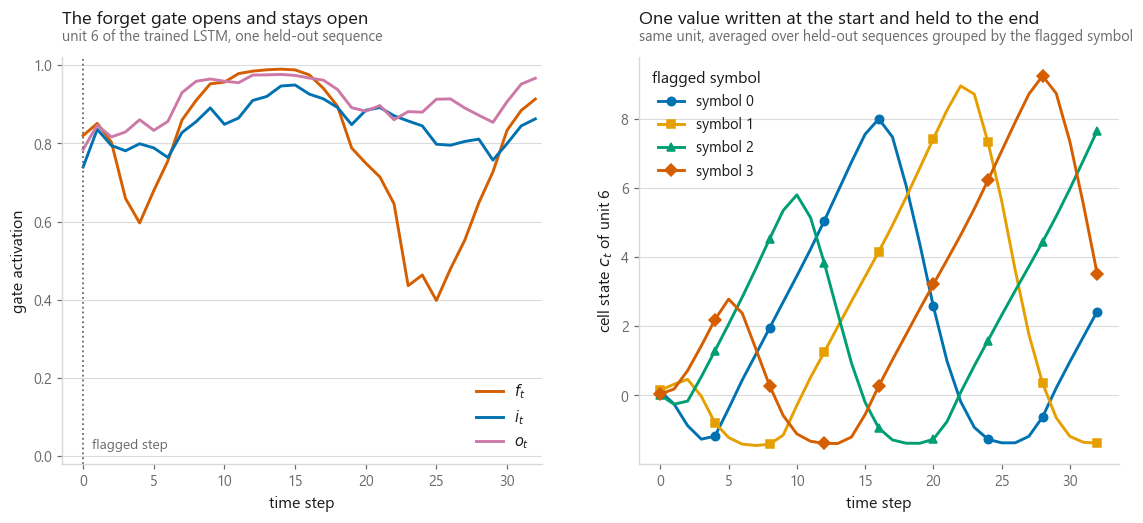

In [22]:
steps = np.arange(GATE_LAG + 1)
seq = 0

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

for name, colour, marker in [("f", style.HIGHLIGHT, None),
                             ("i", style.PALETTE[0], None),
                             ("o", style.PALETTE[4], None)]:
    axes[0].plot(steps, gate_log[name][seq, :, unit].numpy(), color=colour,
                 marker=marker, label=f"${name}_t$")
axes[0].axvline(0, color=style.MUTED, linestyle=":", linewidth=1.2)
axes[0].annotate("flagged step", xy=(0, 0.02), xytext=(6, 0),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_xlim(-1.5, GATE_LAG + 0.5)
axes[0].set_xlabel("time step")
axes[0].set_ylabel("gate activation")
axes[0].legend()
style.title(axes[0],
            "The forget gate opens and stays open" if held > 0.7 else
            "Where this unit's gates settled",
            f"unit {unit} of the trained LSTM, one held-out sequence")

for k in range(N_SYMBOLS):
    mask = torch.from_numpy(y_probe == k)
    if not bool(mask.any()):
        continue
    axes[1].plot(steps, cell_states[mask][:, :, unit].numpy().mean(0),
                 color=style.PALETTE[k], marker=style.MARKERS[k], markevery=4,
                 label=f"symbol {k}")
axes[1].set_xlabel("time step")
axes[1].set_ylabel(f"cell state $c_t$ of unit {unit}")
axes[1].legend(title="flagged symbol")
style.title(axes[1],
            "One value written at the start and held to the end"
            if gate_lag_accuracy >= SOLVED else
            "What this unit carried across the lag",
            "same unit, averaged over held-out sequences grouped by the flagged symbol")

style.save(fig, FIG / "fig-05-gate-activations.png")

Half of my prediction survived the readout. The half that failed is the
interesting one.

The forget gate did what the story says. That unit holds a mean of 0.801 across
the steps after the flag, above the 0.742 average over all units, which is what
"keep what you have" looks like when it has to be a number between zero and one.

The input gate did the opposite of the prediction. I said it would shut after the
flagged step so the distractors could not overwrite the stored symbol. It sits at
a mean of 0.744 at the flagged step and 0.854 afterwards: wider open once the
distractors arrive than at the moment it was supposed to be writing. So the
distractors are being written into the cell, and the unit still carries the right
answer to the end, which the right panel shows and the 1.000 held-out accuracy
confirms. Whatever protects the stored value, it is not a closed input gate. The
forget gate and the weights that feed the candidate have to be arranging it
between them, and this readout does not tell me which.

That is worth leaving in rather than tidying away. The tidy story about gates is
a story about what the architecture makes possible, not a description of what any
particular trained cell does. Nobody designed these traces. The gates are
ordinary logistic layers trained by gradient descent on nothing but the final
classification loss, and what the chart shows is what minimising that loss
produced, whether or not it matches the diagram.

## Cheat sheet

| | |
|---|---|
| **The two states** | $h_t$ is what the network reports, $c_t$ is what it remembers. `nn.LSTM` returns `(output, (h_n, c_n))`, a tuple where `nn.RNN` returns one tensor |
| **The update** | `c = f * c_prev + i * g`, then `h = o * tanh(c)`. Elementwise multiplies and one addition |
| **Why it works** | $\partial c_t / \partial c_{t-1} = \operatorname{diag}(f_t)$. No weight matrix, no $\tanh'$, so the decay rate is learned rather than fixed by a shared spectrum |
| **Gate order** | PyTorch stacks $[i, f, g, o]$ in `weight_ih_l0`; a GRU stacks $[r, z, n]$. Slice `H:2H` is the memory gate in both |
| **Forget bias** | Initialise it near 1. At the default the gate sits at one half and the T=100 gradient is 2.505e-21: six orders of magnitude above the plain RNN's 2.782e-27, and thirteen below the same cell with the bias at 1. Better than an RNN, still dead |
| **Cost** | Four weight blocks against the RNN's one, so four times the parameters at the same hidden size, and slower per step |
| **GRU** | Two gates, one state, three blocks. Roughly three quarters of an LSTM's parameters and usually within noise of its accuracy |
| **Clipping** | Still worth having. Gating fixes vanishing, not exploding |
| **Choosing** | Long dependencies favour gates. Short windows on a periodic series often do not, and a linear model on the lags is the honest test |

## What to remember

1. The LSTM adds a second state whose update is an addition, not a matrix
   multiply. That one structural change is what the rest of the architecture
   exists to control.
2. The gradient along the cell state is a product of forget gates. It is still
   exponential, but the base is learned per unit and per step instead of being
   fixed by one shared matrix.
3. Repeating the RNN notebook's gradient measurement with gated cells shows the
   first-step gradient surviving far longer. Same code, same lengths, same seeds.
4. The forget-gate bias sets that decay rate almost on its own. Left at the
   default it starts near one half, which is why initialising it high is standard
   and why the effect is worth measuring rather than trusting.
5. The copy task did not separate the architectures. All three solved lag 32 and
   all three sat on chance at lag 64. Build the task that isolates the property
   you are testing, then report what it says when it says nothing.
6. Trained, a plain RNN carried one symbol across thirty-two distractor steps at
   1.000 accuracy, which the gradient sweep on a random cell would not have
   predicted. A gradient measured at initialisation is not a prediction about
   what an optimiser will manage once training has moved the weights.
7. The GRU gets close to the same behaviour with three weight blocks instead of
   four. Try both, and expect the difference to be smaller than the difference
   between either and a plain RNN.
8. On a short horizon over a strongly periodic series, all three cells beat the
   linear model on the lags, the GRU by 38.4% RMSE. Run the baseline first and
   let the table decide, in whichever direction it decides.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-05 GRU, and how it compares to LSTM](../05-gru/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#LSTM` `#RNN` `#PyTorch` `#TimeSeries`
`#MachineLearning` `#Python` `#MLTutorial` `#LearnMachineLearning` `#AI`